In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
import plotly.express as px
from urllib.request import urlopen
import plotly.graph_objects as go
%matplotlib inline

In [129]:
# data = pd.read_csv(r'C:\Users\lucas\Desktop\3rd Semester\02806 - Social data and Visualization\02806_social_data_code\02806_social_data_analysis_group50\assignment1\merged_crime_data.csv')
data = pd.read_csv('merged_crime_data.csv')
data.head()

,Incident Category,Incident Description,Police District,Incident Date,Incident Time,Incident Day of Week,Longitude,Latitude,Incident Year
0,Motor Vehicle Theft,Stolen Automobile,Taraval,2016/03/03,19:30,Thursday,-122.463545,37.707968,2016
1,Motor Vehicle Theft,Stolen Truck,Mission,2014/12/26,15:30,Friday,-122.424435,37.755900,2014
2,Missing Person,Missing Adult,Park,2014/11/24,10:00,Monday,-122.437536,37.777844,2014
3,Missing Person,Missing Adult,Southern,2015/03/06,20:00,Friday,-122.396759,37.773173,2015
4,Larceny Theft,Grand Theft From Locked Auto,Southern,2005/10/21,10:15,Friday,-120.500000,90.000000,2005


In [130]:
data['Incident Date'] = pd.to_datetime(data['Incident Date'])

In [131]:
print(data['Incident Category'].unique())

<StringArray>
[       'Motor Vehicle Theft',             'Missing Person',
              'Larceny Theft',                      'Arson',
                    'Robbery',                  'Vandalism',
                'Weapon Laws',                   'Burglary',
             'Drug Violation',            'Stolen Property',
 'Forgery And Counterfeiting',               'Prostitution',
               'Embezzlement']
Length: 13, dtype: str


# 1. Static Graph

In [132]:
# Create a heat map of crime incidents by day of the week and hour of the day

# Filter category + year (change these if you want a different crime)
df = data.copy()
# Build datetime from Date + Time
date_str = df["Incident Date"].astype(str).str.strip().str.replace("-", "/", regex=False)
time_str = df["Incident Time"].astype(str).str.strip()

df["dt"] = pd.to_datetime(date_str + " " + time_str, errors="coerce")
df = df.dropna(subset=["dt"])

# Make dt the index (this is key for time series)
df = df.set_index("dt").sort_index()

print("Rows:", len(df))
print("Index dtype:", df.index.dtype)

Rows: 1601737
Index dtype: datetime64[us]


In [133]:
df_heat = df.copy()
df_heat["hour"] = df_heat.index.hour
df_heat["dow"] = df_heat.index.dayofweek  # Mon=0 ... Sun=6

In [134]:
heat = (
    df_heat.groupby(["dow", "hour"])
    .size()
    .unstack(fill_value=0)     # columns = hours, rows = dow
    .reindex(index=range(7), columns=range(24), fill_value=0)
)

heat.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

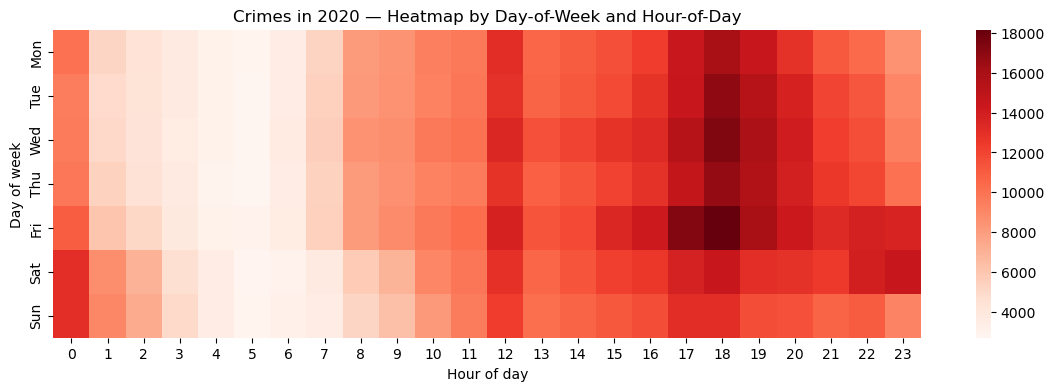

In [135]:
plt.figure(figsize=(14, 4))
sns.heatmap(heat, cmap="Reds")
plt.title("Crimes in 2020 — Heatmap by Day-of-Week and Hour-of-Day")
plt.xlabel("Hour of day")
plt.ylabel("Day of week")
plt.show()

In [136]:
# create dataset precovid dataset from march 2019 to february 2020 using incident date 
df_precovid = data[(data['Incident Date'] >= '2019-03-01') & (data['Incident Date'] < '2020-03-01')]
print(df_precovid.head())
# create dataset duringcovid dataset from march 2020 to february 2021 using incident date
df_duringcovid = data[(data['Incident Date'] >= '2020-03-01') & (data['Incident Date'] < '2021-03-01')]
print(df_duringcovid.head())
# Create dataset of postcovid
df_postcovid = data[(data['Incident Date'] >= '2021-03-01') & (data['Incident Date'] < '2022-03-01')]
print(df_postcovid.head())

        Incident Category                               Incident Description  \
1078969           Robbery                                  Robbery, W/ Force   
1082712      Embezzlement              Embezzlement, Grand Theft By Employee   
1084385     Larceny Theft  Embezzlement from Dependent or Elder Adult by ...   
1086232     Larceny Theft                           Theft, Grand, of Firearm   
1095305     Larceny Theft  Embezzlement from Dependent or Elder Adult by ...   

        Police District Incident Date Incident Time Incident Day of Week  \
1078969        Southern    2020-01-12         19:30               Sunday   
1082712      Tenderloin    2020-01-01         00:00            Wednesday   
1084385      Tenderloin    2020-01-01         00:00            Wednesday   
1086232        Southern    2019-12-03         19:00              Tuesday   
1095305            Park    2019-07-01         00:00               Monday   

          Longitude   Latitude  Incident Year  
1078969 -122.4

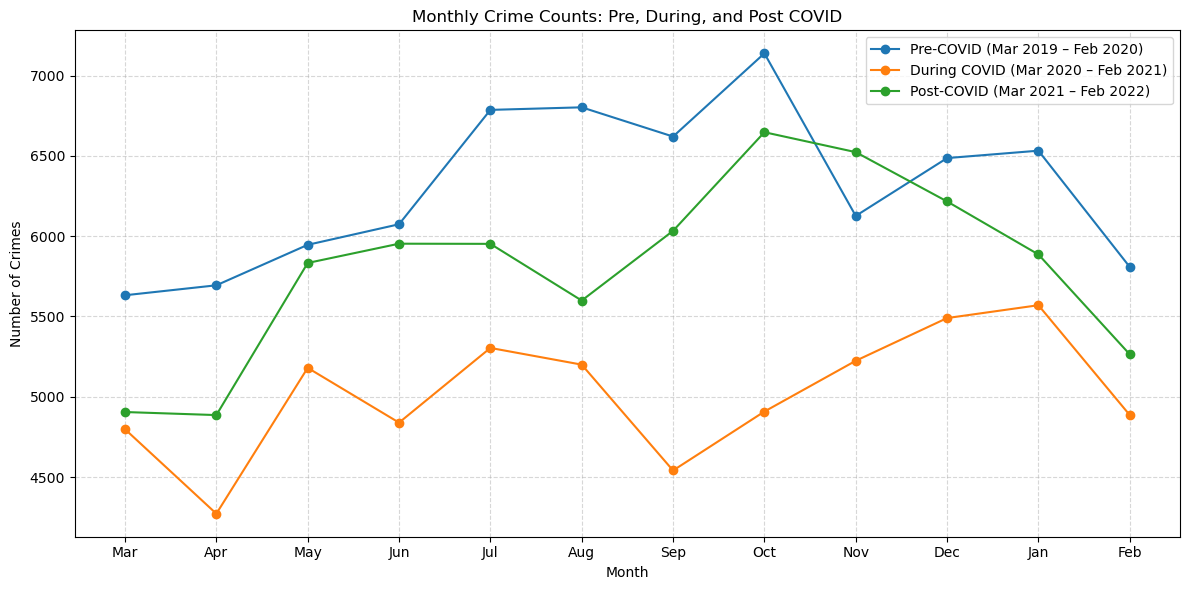

In [137]:
import matplotlib.pyplot as plt

# Count crimes per month for each period
precovid_monthly = df_precovid.groupby(df_precovid['Incident Date'].dt.month).size()
duringcovid_monthly = df_duringcovid.groupby(df_duringcovid['Incident Date'].dt.month).size()
postcovid_monthly = df_postcovid.groupby(df_postcovid['Incident Date'].dt.month).size()

# Month labels starting from March (month 3) to February (month 2)
month_order = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2]
month_labels = ['Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb']

# Reindex so all three lines follow Mar → Feb order
precovid_ordered = [precovid_monthly.get(m, 0) for m in month_order]
duringcovid_ordered = [duringcovid_monthly.get(m, 0) for m in month_order]
postcovid_ordered = [postcovid_monthly.get(m, 0) for m in month_order]

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(month_labels, precovid_ordered, marker='o', label='Pre-COVID (Mar 2019 – Feb 2020)')
ax.plot(month_labels, duringcovid_ordered, marker='o', label='During COVID (Mar 2020 – Feb 2021)')
ax.plot(month_labels, postcovid_ordered, marker='o', label='Post-COVID (Mar 2021 – Feb 2022)')

ax.set_xlabel('Month')
ax.set_ylabel('Number of Crimes')
ax.set_title('Monthly Crime Counts: Pre, During, and Post COVID')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
fig.savefig('static_crime_trends_covid.png', dpi=300)
plt.show()

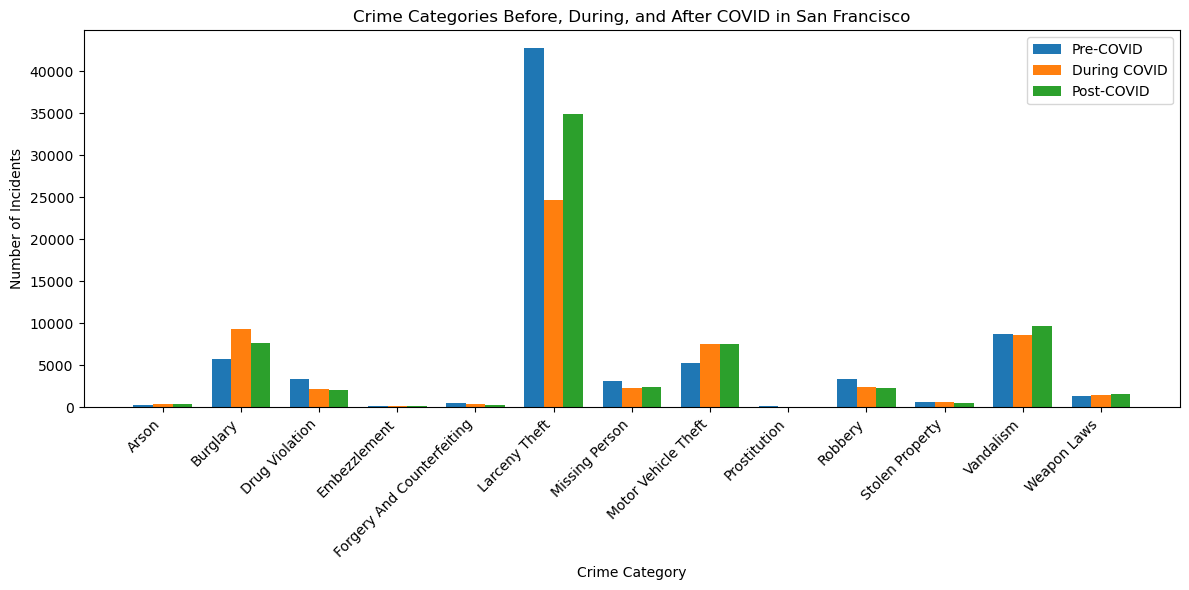

In [138]:
# Count incidents per crime type in each period
pre_counts = df_precovid['Incident Category'].value_counts()
during_counts = df_duringcovid['Incident Category'].value_counts()
post_counts = df_postcovid['Incident Category'].value_counts()

# Combine into one dataframe
crime_counts = pd.DataFrame({
    'Pre-COVID': pre_counts,
    'During COVID': during_counts,
    'Post-COVID': post_counts
}).fillna(0)

# Plot
x = np.arange(len(crime_counts.index))
width = 0.25  # smaller width to fit 3 bars
plt.close()
plt.figure(figsize=(12, 6))

plt.bar(x - width, crime_counts['Pre-COVID'], width, label='Pre-COVID')
plt.bar(x, crime_counts['During COVID'], width, label='During COVID')
plt.bar(x + width, crime_counts['Post-COVID'], width, label='Post-COVID')

plt.xticks(x, crime_counts.index, rotation=45, ha='right')
plt.xlabel('Crime Category')
plt.ylabel('Number of Incidents')
plt.title('Crime Categories Before, During, and After COVID in San Francisco')
plt.legend()

plt.tight_layout()
plt.savefig('static_crime_category_comparison.png', dpi=300)
plt.show()
# save plot

In the above plot it is noticeably burglary and motor vehicle theft that increases. If would be interesting to see the distribution of spatially whether these occur mostly in rural or urban areas.

Maybe answer the question what crimes increase during pandemics and what crimes decrease

Another reasearch question is what crimes are most correlated,

# 2. Map

In [127]:
import folium
from folium import plugins
from folium.plugins import HeatMap

ModuleNotFoundError: No module named 'folium'

In [ ]:
# Redefine m every run so the state is always clean
m = folium.Map(location=[37.7749, -122.4194], zoom_start=13)

In [ ]:
# 
#df_foc = df_duringcovid[(df_duringcovid['Incident Category'] == 'Burglary') | (df_duringcovid['Incident Category'] == 'Motor Vehicle Theft')]
df_foc = df_duringcovid[(df_duringcovid['Incident Category'] == 'Burglary')]
df_foc['Incident Date'] = pd.to_datetime(df_foc['Incident Date'])

C:\Users\lucas\AppData\Local\Temp\ipykernel_26016\3785136610.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_foc['Incident Date'] = pd.to_datetime(df_foc['Incident Date'])


In [ ]:
# Creating a heatmap passing the lat and long of the prostitution crimes
heat_data = [[row['Latitude'], row['Longitude']] for index, row in df_foc.iterrows()]
HeatMap(heat_data, radius=10, blur=5).add_to(m)
m.save("heatmap_burglary.html")
m

# 2. Choropleth Map

A chloropeth map with ratios of the change between precovid and during covid with seperate districts.

In [139]:
df_duringcovid.info()

<class 'pandas.DataFrame'>
Index: 60212 entries, 1077982 to 1601715
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Incident Category     60212 non-null  str           
 1   Incident Description  60212 non-null  str           
 2   Police District       60212 non-null  str           
 3   Incident Date         60212 non-null  datetime64[us]
 4   Incident Time         60212 non-null  str           
 5   Incident Day of Week  60212 non-null  str           
 6   Longitude             60212 non-null  float64       
 7   Latitude              60212 non-null  float64       
 8   Incident Year         60212 non-null  int64         
dtypes: datetime64[us](1), float64(2), int64(1), str(5)
memory usage: 4.6 MB


In [140]:
df_precovid.info()

<class 'pandas.DataFrame'>
Index: 75644 entries, 1078969 to 1600578
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Incident Category     75644 non-null  str           
 1   Incident Description  75644 non-null  str           
 2   Police District       75644 non-null  str           
 3   Incident Date         75644 non-null  datetime64[us]
 4   Incident Time         75644 non-null  str           
 5   Incident Day of Week  75644 non-null  str           
 6   Longitude             75644 non-null  float64       
 7   Latitude              75644 non-null  float64       
 8   Incident Year         75644 non-null  int64         
dtypes: datetime64[us](1), float64(2), int64(1), str(5)
memory usage: 5.8 MB


In [141]:
df_precovid['Incident Category'].unique()

<StringArray>
[                   'Robbery',               'Embezzlement',
              'Larceny Theft',                'Weapon Laws',
             'Missing Person',                      'Arson',
               'Prostitution',                  'Vandalism',
        'Motor Vehicle Theft',                   'Burglary',
             'Drug Violation', 'Forgery And Counterfeiting',
            'Stolen Property']
Length: 13, dtype: str

### Data Preparation

In [142]:
# Filter to burglary incidents only
burglary_during = df_duringcovid[df_duringcovid['Incident Category'] == 'Burglary']
burglary_pre    = df_precovid[df_precovid['Incident Category'] == 'Burglary']
counts_during = burglary_during.groupby('Police District').size()
counts_pre    = burglary_pre.groupby('Police District').size()

# ratio df
df_ratio_burglary = pd.DataFrame({'during': counts_during, 'pre': counts_pre})

# ratio
df_ratio_burglary['ratio'] = df_ratio_burglary['during'] / df_ratio_burglary['pre']

# keep only needed columns
df_ratio_burglary = df_ratio_burglary.reset_index()
df_ratio_burglary = df_ratio_burglary.rename(columns={'Police District': 'district'})
df_ratio_burglary = df_ratio_burglary[['district', 'ratio']]

# Uppercase district names to match geojson
df_ratio_burglary['district'] = df_ratio_burglary['district'].str.upper()

In [143]:
# Filter to motor vehicle theft incidents only
mvt_during = df_duringcovid[df_duringcovid['Incident Category'] == 'Motor Vehicle Theft']
mvt_pre    = df_precovid[df_precovid['Incident Category'] == 'Motor Vehicle Theft']
counts_during = mvt_during.groupby('Police District').size()
counts_pre    = mvt_pre.groupby('Police District').size()

# ratio df
df_ratio_mvt = pd.DataFrame({'during': counts_during, 'pre': counts_pre})

# ratio
df_ratio_mvt['ratio'] = df_ratio_mvt['during'] / df_ratio_mvt['pre']

# keep only needed columns
df_ratio_mvt = df_ratio_mvt.reset_index()
df_ratio_mvt = df_ratio_mvt.rename(columns={'Police District': 'district'})
df_ratio_mvt = df_ratio_mvt[['district', 'ratio']]

# Uppercase district names to match geojson
df_ratio_mvt['district'] = df_ratio_mvt['district'].str.upper()

In [144]:
df_ratio_burglary

,district,ratio
0,BAYVIEW,1.152220
1,CENTRAL,1.379531
2,INGLESIDE,1.207447
3,MISSION,1.851667
4,NORTHERN,2.015690
5,PARK,2.348348
6,RICHMOND,2.393768
7,SOUTHERN,1.377515
8,TARAVAL,1.578164
9,TENDERLOIN,1.363309


In [145]:
df_ratio_mvt

,district,ratio
0,BAYVIEW,1.517241
1,CENTRAL,1.031621
2,INGLESIDE,1.905145
3,MISSION,1.379056
4,NORTHERN,1.433544
5,PARK,1.514085
6,RICHMOND,1.456576
7,SOUTHERN,1.165480
8,TARAVAL,1.383659
9,TENDERLOIN,1.418699


In [146]:
with urlopen('https://raw.githubusercontent.com/suneman/socialdata2025/main/files/sfpd.geojson') as response:
    districts = json.load(response)

### Choropleth visualization

In [155]:
fig1 = px.choropleth_map(
    df_ratio_burglary,
    geojson=districts,
    locations='district',
    color='ratio',
    color_continuous_scale="RdYlGn",
    range_color=(0, 2),
    map_style="carto-positron",
    zoom=11,
    center={"lat": 37.745, "lon": -122.46},
    opacity=0.7,
    labels={'ratio': 'During/Pre-COVID Ratio'},
    hover_name='district',
    hover_data={'ratio': ':.2f'},
    title="Burglary"
)


fig2 = px.choropleth_map(
    df_ratio_mvt,
    geojson=districts,
    locations='district',
    color='ratio',
    color_continuous_scale="RdYlGn",
    range_color=(0, 2),
    map_style="carto-positron",
    zoom=11,
    center={"lat": 37.745, "lon": -122.46},
    opacity=0.7,
    labels={'ratio': 'During/Pre-COVID Ratio'},
    hover_name='district',
    hover_data={'ratio': ':.2f'},
    title="Motor Vehicle Theft"
)

# --- Combine ---
# Take the MVT trace and bind it to a second mapbox
mvt_trace = fig2.data[0]
mvt_trace.update(coloraxis="coloraxis", subplot="map2")  # share coloraxis, use mapbox2

fig1.add_trace(mvt_trace)

fig1.update_layout(
    title=dict(
        text="Burglary and Motor Vehicle Theft - During/Pre-COVID Ratio by District",
        font=dict(family="Inter, Arial, sans-serif", size=14),
        x=0.5, xanchor="center",
        y=0.98
    ),
    map=dict(
        style="carto-positron",
        center={"lat": 37.745, "lon": -122.46},
        zoom=10.5,
        domain={"x": [0, 0.497], "y": [0.02, 1]}
    ),
    map2=dict(
        style="carto-positron",
        center={"lat": 37.745, "lon": -122.46},
        zoom=10.5,
        domain={"x": [0.502, 0.99], "y": [0.02, 1]}  # cap at 0.94 to leave room for colorbar
    ),
    coloraxis=dict(
        colorscale="RdYlGn",
        cmin=0, cmax=2,
        colorbar=dict(
            title=dict(
                text="During/<br>Pre-COVID",
                font=dict(size=11),
                side="top"
            ),
            tickvals=[0, 0.5, 1.0, 1.5, 2.0],
            ticktext=["0", "0.5", "1.0 ±", "1.5", "2.0"],
            thickness=12,
            len=0.7,
            x=0.995,                                    # tucked right after map2
            y=0.5,
            yanchor="middle",
            tickfont=dict(size=10),
            bgcolor="rgba(0,0,0,0)",                   # fully transparent background
            borderwidth=0,
            outlinewidth=0
        )
    ),
    annotations=[
        dict(text="Burglary", x=0.235, y=0.97, xref="paper", yref="paper",
             showarrow=False, font=dict(size=12, family="Inter, Arial, sans-serif", color="#444")),
        dict(text="Motor Vehicle Theft", x=0.72, y=0.97, xref="paper", yref="paper",
             showarrow=False, font=dict(size=12, family="Inter, Arial, sans-serif", color="#444")),
    ],
    margin={"r": 80, "t": 30, "l": 0, "b": 0},       # tight margins all around
    font=dict(family="Inter, Arial, sans-serif", size=11),
    width=850,
    height=480                                         # less tall = less dead vertical space
)

fig1.show()

In [150]:
# save to html
fig1.write_html("crime_ratio_districts_maps.html")

# 3. Interactive Plotly Visualization

A plot with selected interesting districts (possibility to choose the districts) and data for both precovid and during covid to compare the hourly distribution of a week.

### Data Preparation

In [ ]:
# hour column 
df_duringcovid['hour'] = pd.to_datetime(df_duringcovid['Incident Time'], format='%H:%M').dt.hour
df_precovid['hour']    = pd.to_datetime(df_precovid['Incident Time'], format='%H:%M').dt.hour

# week day
day_order = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2,
             'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6}

df_duringcovid['day_num'] = df_duringcovid['Incident Day of Week'].map(day_order)
df_precovid['day_num']    = df_precovid['Incident Day of Week'].map(day_order)

# week_hour
df_duringcovid['week_hour'] = df_duringcovid['day_num'] * 24 + df_duringcovid['hour']
df_precovid['week_hour']    = df_precovid['day_num'] * 24 + df_precovid['hour']

df_duringcovid['period'] = 'During COVID'
df_precovid['period']    = 'Pre-COVID'

df_all = pd.concat([df_duringcovid, df_precovid])

# Filter to the two crime types only
crimes = ['Burglary', 'Motor Vehicle Theft']
df_filtered = df_all[df_all['Incident Category'].isin(crimes)]

# Group by all relevant dimensions
df_grouped = (
    df_filtered
    .groupby(['period', 'Incident Category', 'Police District', 'week_hour'])
    .size()
    .reset_index(name='count')
)

df_grouped['Police District'] = df_grouped['Police District'].str.upper()

# Create readable x-axis label: "Mon 00:00", "Mon 01:00" etc.
inv_day_order = {v: k[:3] for k, v in day_order.items()}
df_grouped['day_num']  = df_grouped['week_hour'] // 24
df_grouped['hour_num'] = df_grouped['week_hour'] % 24
df_grouped['week_hour_label'] = (
    df_grouped['day_num'].map(inv_day_order) + ' ' +
    df_grouped['hour_num'].astype(str).str.zfill(2) + ':00'
)

### Interactive Bar Plot

In [152]:
crimes = ['Burglary', 'Motor Vehicle Theft']
periods = ['Pre-COVID', 'During COVID']
all_districts = sorted(df_plot['Police District'].unique())

day_abbr = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
tickvals = [i * 24 for i in range(7)]
ticktext = [day_abbr[i] for i in range(7)]

colors = {
    d: c for d, c in zip(
        all_districts,
        px.colors.qualitative.Safe * (len(all_districts) // len(px.colors.qualitative.Safe) + 1)
    )
}

fig = go.Figure()

# Track trace indices per crime for visibility mask
trace_indices = {crime: [] for crime in crimes}

for crime in crimes:
    for period in periods:
        for district in all_districts:
            mask = (
                (df_plot['Incident Category'] == crime) &
                (df_plot['period'] == period) &
                (df_plot['Police District'] == district)
            )
            df_slice = df_plot[mask].sort_values('week_hour')

            trace_idx = len(fig.data)
            trace_indices[crime].append(trace_idx)

            # Each crime gets its own legendgroup namespace so legends don't bleed across crimes
            fig.add_trace(go.Bar(
                x=df_slice['week_hour'],
                y=df_slice['count'],
                name=district,
                legendgroup=f'{crime}_{district}',       # unique per crime
                legendgrouptitle_text=None,
                showlegend=(period == periods[0]),        # one legend entry per district per crime
                visible=(crime == crimes[0]),
                marker_color=colors[district],
                yaxis='y' if period == 'Pre-COVID' else 'y2',
                customdata=df_slice[['week_hour_label', 'Police District']].values,
                hovertemplate=(
                    f'<b>{period}</b><br>'
                    '%{customdata[0]}<br>'
                    'District: %{customdata[1]}<br>'
                    'Avg incidents: %{y:.2f}<extra></extra>'
                )
            ))

n_total = len(fig.data)

def visibility_mask(selected_crime):
    return [
        crime == selected_crime
        for crime in crimes
        for period in periods
        for district in all_districts
    ]

dropdown_buttons = [
    dict(
        label=crime,
        method='update',
        args=[
            {'visible': visibility_mask(crime)},
            {'title.text': f'{crime} — hourly distribution across the week'}
        ]
    )
    for crime in crimes
]

fig.update_layout(
    xaxis=dict(
        tickvals=tickvals,
        ticktext=ticktext,
        showgrid=True,
        gridcolor='rgba(0,0,0,0.06)',
        zeroline=False,
        domain=[0, 1],
        anchor='y2'
    ),
    # Remove titles from both yaxes
    yaxis=dict(
        title=None,
        showgrid=True,
        gridcolor='rgba(0,0,0,0.06)',
        zeroline=False,
        domain=[0.52, 1]
    ),
    yaxis2=dict(
        title=None,
        showgrid=True,
        gridcolor='rgba(0,0,0,0.06)',
        zeroline=False,
        domain=[0, 0.48],
        anchor='x'
    ),
    barmode='stack',
    bargap=0.05,
    updatemenus=[dict(
        type='dropdown',
        direction='down',
        x=0.0, y=1.06,          # tighter to the top
        xanchor='left',
        showactive=True,
        bgcolor='white',
        bordercolor='#ddd',
        font=dict(size=11, family='Inter, Arial, sans-serif'),
        buttons=dropdown_buttons
    )],
    shapes=[
        dict(
            type='line', xref='x', yref='paper',
            x0=day * 24 - 0.5, x1=day * 24 - 0.5,
            y0=0, y1=1,
            line=dict(color='rgba(0,0,0,0.12)', width=1, dash='dot')
        )
        for day in range(1, 7)
    ],
    title=dict(
        text='Burglary — hourly distribution across the week',
        font=dict(family='Inter, Arial, sans-serif', size=13),
        x=0.5, xanchor='center', y=0.99
    ),
    legend=dict(
        title=dict(text='District<br><sup>click to toggle</sup>', font=dict(size=10)),
        orientation='v',
        x=1.03, y=0.5,
        bgcolor='rgba(0,0,0,0)',
        borderwidth=0,
        font=dict(size=10),
        tracegroupgap=2
    ),
    # Replace with manually positioned annotations for all four labels
    annotations=[
        # Y-axis titles — same x, vertically centred within each panel
        dict(
            text='Avg. incidents',
            x=-0.035, y=0.85,            # horizontally fixed, centred in top panel
            xref='paper', yref='paper',
            showarrow=False, textangle=-90,
            font=dict(size=11, color='#888'),
            xanchor='center'
        ),
        dict(
            text='Avg. incidents',
            x=-0.035, y=0.15,            # same x, centred in bottom panel
            xref='paper', yref='paper',
            showarrow=False, textangle=-90,
            font=dict(size=11, color='#888'),
            xanchor='center'
        ),
        # Period labels — same x on the right, same y positions mirror the left
        dict(
            text='Pre-COVID',
            x=1.015, y=0.85,
            xref='paper', yref='paper',
            showarrow=False, textangle=90,
            font=dict(size=11, color='#888'),
            xanchor='center'
        ),
        dict(
            text='During COVID',
            x=1.015, y=0.15,
            xref='paper', yref='paper',
            showarrow=False, textangle=90,
            font=dict(size=11, color='#888'),
            xanchor='center'
        ),
    ],
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Inter, Arial, sans-serif', size=11, color='#333'),
    margin=dict(r=100, t=50, l=60, b=30),   # tighter margins all round
    height=520,                               # reduced height
    width=850                                # reduced width
)

fig.show()

In [ ]:
# save to html
fig.write_html("crime_hourly_dist_interctive.html")